# Evaluation Suite for HyperParam Search Results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
import robomimic.dev.hparam.metric_fn as Metrics
import copy
from robomimic.dev.hparam.eval_suite import HparamAnalyzer
from matplotlib.collections import PolyCollection
import seaborn as sns

In [2]:
result_dir = '/home/wjung85/Repo/projects/FastIL/logs/hparam'
baseline_dir = '/home/wjung85/Repo/projects/FastIL/logs/baseline'

In [3]:
import pickle
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_cls_f_ts_20_eta_0_nres_0_loss_mse_wg_10_nsmc_1_stdmc_0_iter_0_2025-01-08 11:11:44.394144.pkl"
with open(pkl_path, "rb") as f:
    data_peek = pickle.load(f)

stat_peek = data_peek["stats"]
demo_peek = data_peek["rollouts"]["demo_0"]

### Loading Result of Baseline (Square)

In [4]:
ldlj_analyzer_bl_success    = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.ldlj_pos_eval_fn), level = "demo", filter="inp")
ldlj_analyzer_bl            = HparamAnalyzer(baseline_dir, Metrics.ldlj_pos_eval_fn, level = "demo", filter="inp")
sparc_analyzer_bl_success   = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.sparc_pos_eval_fn), level = "demo", filter="inp")
sparc_analyzer_bl           = HparamAnalyzer(baseline_dir, Metrics.sparc_pos_eval_fn, level = "demo", filter="inp")
horizon_analyzer_bl_success = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.horizon_eval_fn), level = "demo", filter="inp")
horizon_analyzer_bl         = HparamAnalyzer(baseline_dir, Metrics.horizon_eval_fn, level = "demo", filter="inp")
avg_success_analyzer_bl       = HparamAnalyzer(baseline_dir, Metrics.average_success_eval_fn, level = "stat", filter="inp")
inftime_analyzer_bl           = HparamAnalyzer(baseline_dir, Metrics.average_inftime_eval_fn, level = "demo", filter="inp")
sparc_knot_analyzer_bl          = HparamAnalyzer(baseline_dir, Metrics.sparc_pos_real_at_knot_eval_fn, level = "demo", filter="inp")
sparc_knot_analyzer_bl_success  = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.sparc_pos_real_at_knot_eval_fn), level = "demo", filter="inp")

100%|██████████| 6/6 [00:01<00:00,  5.50it/s]


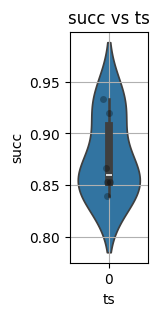

In [35]:
_ = avg_success_analyzer_bl.plot_hparam_comparison(x_param='ts', plot_type='violin', figsize=(1, 3), metric_name = "succ")

### Loading Result of Guiding (Square)

In [5]:

ldlj_analyzer_inp            = HparamAnalyzer(result_dir, Metrics.ldlj_pos_eval_fn, level = "demo", filter="cls")
# sparc_analyzer_inp_success   = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.sparc_pos_eval_fn), level = "demo", filter="cls")
sparc_analyzer_inp          = HparamAnalyzer(result_dir, Metrics.sparc_pos_eval_fn, level = "demo", filter="cls")
# horizon_analyzer_inp_success = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.horizon_eval_fn), level = "demo", filter="inp")
# horizon_analyzer_inp         = HparamAnalyzer(result_dir, Metrics.horizon_eval_fn, level = "demo", filter="inp")
avg_success_analyzer_inp       = HparamAnalyzer(result_dir, Metrics.average_success_eval_fn, level = "stat", filter="cls")
inftime_analyzer_inp           = HparamAnalyzer(result_dir, Metrics.average_inftime_eval_fn, level = "demo", filter="cls")
# sparc_knot_analyzer_inp          = HparamAnalyzer(result_dir, Metrics.sparc_pos_real_at_knot_eval_fn, level = "demo", filter="cls")
# sparc_knot_analyzer_inp_success  = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.sparc_pos_real_at_knot_eval_fn), level = "demo", filter="inp")

100%|██████████| 1194/1194 [05:09<00:00,  3.86it/s]


In [6]:
sparc_analyzer_inp_success   = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.sparc_pos_eval_fn), level = "demo", filter="cls")
ldlj_analyzer_inp_success    = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.ldlj_pos_eval_fn), level = "demo", filter="cls")

100%|██████████| 1204/1204 [05:15<00:00,  3.82it/s]


### Inference Time

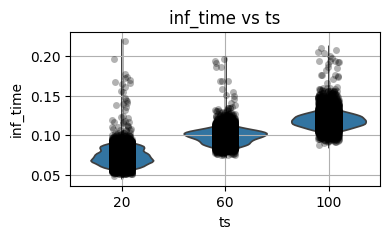

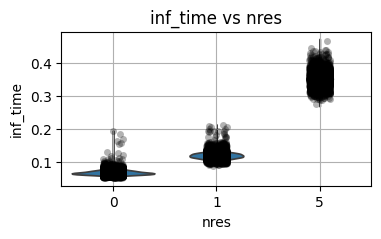

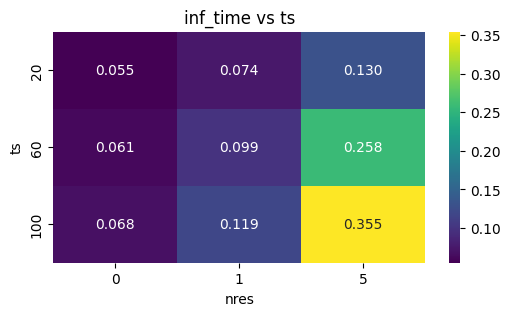

In [7]:
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(4, 2), metric_name = "inf_time")
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts":100}, figsize=(4, 2), metric_name = "inf_time")
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "inf_time")

### Success Rate

In [11]:
print(df.columns)
df["wg"].unique()

Index(['ts', 'eta', 'nres', 'iter', 'loss', 'wg', 'nsmc', 'stdmc', 'cls',
       'square_image', 'inp', 'metric_value', 'metric_index'],
      dtype='object')


array([  10,  100, 1000])

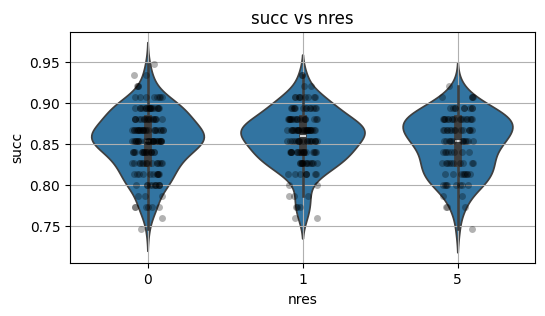

In [46]:
df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"wg":10}, figsize=(6, 3), metric_name = "succ")
# avg_success_analyzer_inp.get_best_config(True)
# df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts":100}, figsize=(6, 3), metric_name = "succ")
# df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='eta', plot_type='violin', figsize=(6, 3), metric_name = "succ")
# df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "succ")

,ts,eta,nres,iter,loss,wg,nsmc,stdmc,cls,square_image,inp,metric_value,metric_index
450,60,1,1,0,mse,100,1,0,True,True,False,-25.833258,0
451,60,1,1,0,mse,100,1,0,True,True,False,-19.581480,1
452,60,1,1,0,mse,100,1,0,True,True,False,-19.718409,2
453,60,1,1,0,mse,100,1,0,True,True,False,-25.983858,3
454,60,1,1,0,mse,100,1,0,True,True,False,-17.572078,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89245,100,1,1,1,weighted_mse,1000,4,0,True,True,False,-27.699334,70
89246,100,1,1,1,weighted_mse,1000,4,0,True,True,False,-27.407215,71
89247,100,1,1,1,weighted_mse,1000,4,0,True,True,False,-27.388552,72
89248,100,1,1,1,weighted_mse,1000,4,0,True,True,False,-27.786686,73


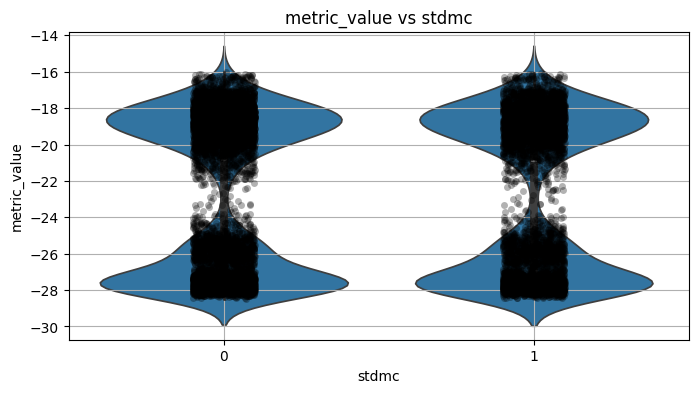

In [53]:
ldlj_analyzer_inp.plot_hparam_comparison(x_param='stdmc', plot_type='violin', fixed_params={"nres": 1, "eta": 1}, figsize=(8,4))

In [34]:
inftime_analyzer = HparamAnalyzer(result_dir, Metrics.inftime_eval_fn, level="demo", filter="inp")

100%|██████████| 126/126 [00:20<00:00,  6.11it/s]


ValueError: Can not reset the axes.  You are probably trying to re-use an artist in more than one Axes which is not supported

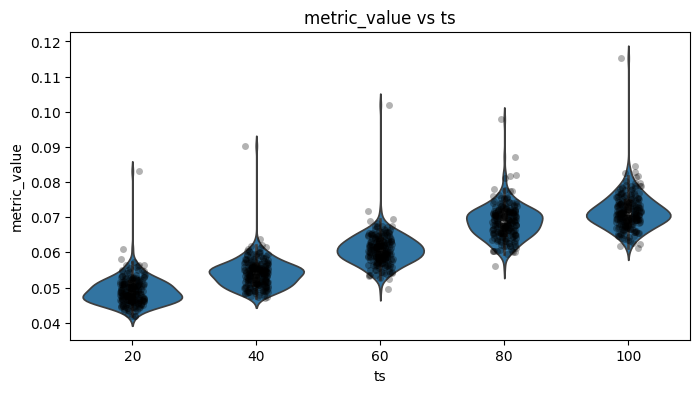

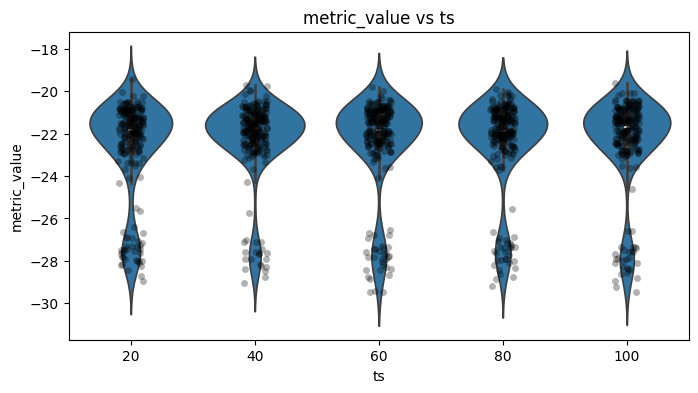

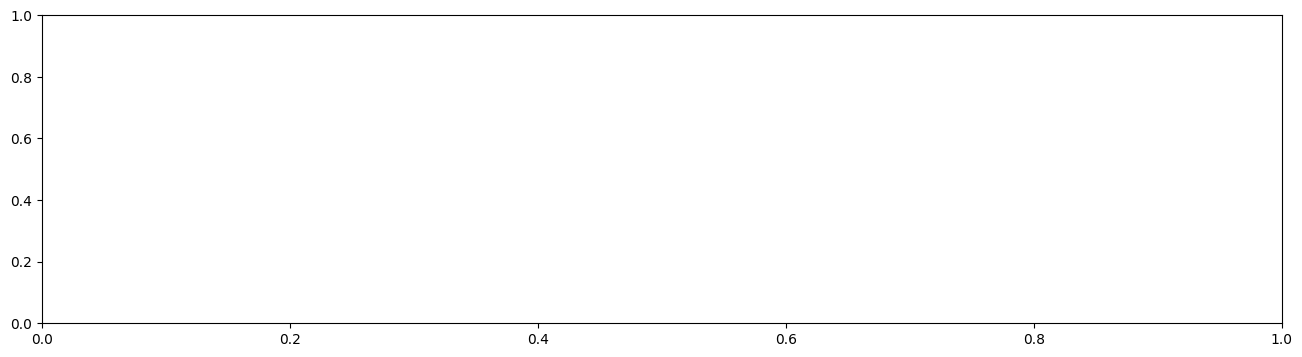

In [29]:
df1 = inftime_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True, "nres": 1, "eta": 0}, figsize=(8,4))
df2 = ldlj_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True, "nres": 1, "eta": 0}, figsize=(8,4))

### Evaluation Function Suite

### Success Rate Evaluation

### Average Horizon Evaluation

### Inferenece Time